## Supervised Learning Bonus

In this notebook, I practice supervised learning concepts from the lecture using the Spotify dataset.

In [ ]:
import pandas as pd

df = pd.read_csv("../data/spotify_cleaned_unique_tracks.csv")
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic,3.314217


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic,3.314217


In [ ]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

X = df[features]
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


### Feature Selection

I use numerical audio features that describe the sound and style of each song.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

X = df[features].copy()

# Kontrollera missing values
print(X.isna().sum())

# Ta bort rader med missing values i features
df_model = df.dropna(subset=features).copy()
X = df_model[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model["cluster"] = kmeans.fit_predict(X_scaled)

df_model["cluster"].value_counts()

danceability          0
energy                0
loudness              0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo               157
dtype: int64


cluster
1    39691
2    30390
0    19502
Name: count, dtype: int64

In [ ]:
X = df_model[features]
y = df_model["cluster"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Scaling

I fit the scaler only on the training data and then transform both training and test data.

This prevents data leakage and makes the evaluation more fair.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

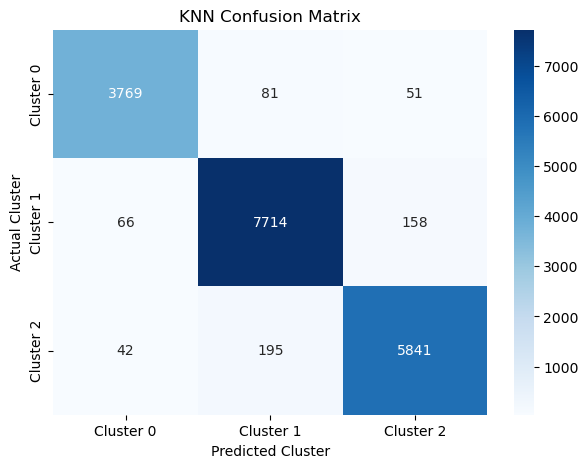

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cluster 0", "Cluster 1", "Cluster 2"],
    yticklabels=["Cluster 0", "Cluster 1", "Cluster 2"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual Cluster")
plt.show()

### Confusion Matrix

The confusion matrix shows how well the KNN model predicts the cluster labels.

Each row represents the actual cluster, and each column represents the predicted cluster.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3901
           1       0.97      0.97      0.97      7938
           2       0.97      0.96      0.96      6078

    accuracy                           0.97     17917
   macro avg       0.97      0.97      0.97     17917
weighted avg       0.97      0.97      0.97     17917



### Classification Report

The classification report shows precision, recall and F1-score for each cluster.
These metrics help evaluate how well the model performs for every group.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    scores.append(score)

k_results = pd.DataFrame({
    "k": k_values,
    "accuracy": scores
})

k_results

,k,accuracy
0,1,0.958252
1,3,0.963833
2,5,0.966903
3,7,0.968968
4,9,0.970866
5,11,0.972038
6,15,0.973210
7,21,0.973489


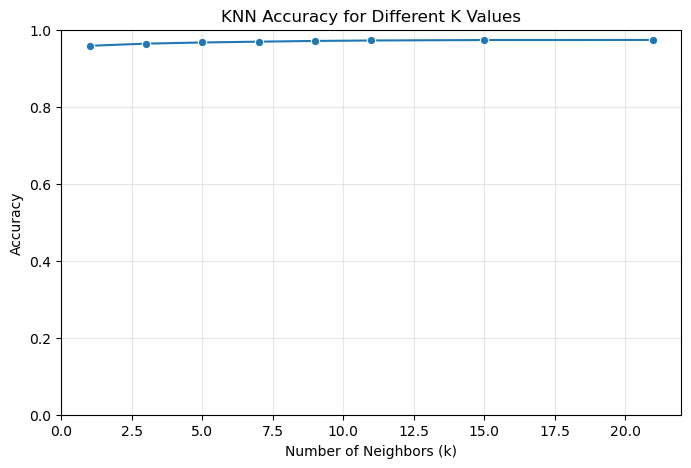

In [ ]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=k_results, x="k", y="accuracy", marker="o")
plt.title("KNN Accuracy for Different K Values")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

### Testing Different K Values

I tested several values of k to see how the number of neighbors affects model performance.

This helps choose a more stable and reliable KNN model.

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=3)

X_test_pca = pca.fit_transform(X_test_scaled)

plot_df = pd.DataFrame({
    "PCA 1": X_test_pca[:, 0],
    "PCA 2": X_test_pca[:, 1],
    "PCA 3": X_test_pca[:, 2],
    "Actual Cluster": y_test.astype(str).values,
    "Predicted Cluster": y_pred.astype(str)
})

fig = px.scatter_3d(
    plot_df,
    x="PCA 1",
    y="PCA 2",
    z="PCA 3",
    color="Predicted Cluster",
    symbol="Actual Cluster",
    title="3D PCA Visualization of KNN Predictions"
)

fig.show()

In [ ]:
fig.write_html("knn_predictions_3d.html")

In [ ]:
import plotly.express as px
from sklearn.decomposition import PCA
import pandas as pd
import webbrowser
import os

# PCA
pca = PCA(n_components=3)
X_test_pca = pca.fit_transform(X_test_scaled)

plot_df = pd.DataFrame({
    "PCA 1": X_test_pca[:, 0],
    "PCA 2": X_test_pca[:, 1],
    "PCA 3": X_test_pca[:, 2],
    "Actual": y_test.astype(str).values,
    "Predicted": y_pred.astype(str)
})

fig = px.scatter_3d(
    plot_df,
    x="PCA 1",
    y="PCA 2",
    z="PCA 3",
    color="Predicted",
    symbol="Actual",
    title="3D PCA Visualization of KNN Predictions"
)

# Spara fil
file_path = "knn_predictions_3d.html"
fig.write_html(file_path)

# Öppna i webbläsare
full_path = os.path.abspath(file_path)
webbrowser.open("file://" + full_path)

True

### 3D PCA Visualization

I used PCA to reduce the test data into three dimensions and visualized the KNN predictions in 3D.

The colors show the predicted clusters, while the symbols show the actual clusters.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)

dt_score = dt.score(X_test_scaled, y_test)
knn_score = knn.score(X_test_scaled, y_test)

print("KNN accuracy:", round(knn_score, 3))
print("Decision Tree accuracy:", round(dt_score, 3))

KNN accuracy: 0.967
Decision Tree accuracy: 0.878


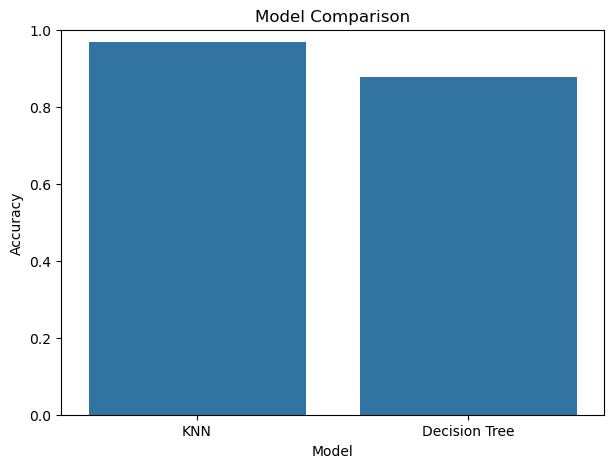

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["KNN", "Decision Tree"],
    "Accuracy": [knn_score, dt_score]
})

plt.figure(figsize=(7, 5))
sns.barplot(data=model_comparison, x="Model", y="Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()

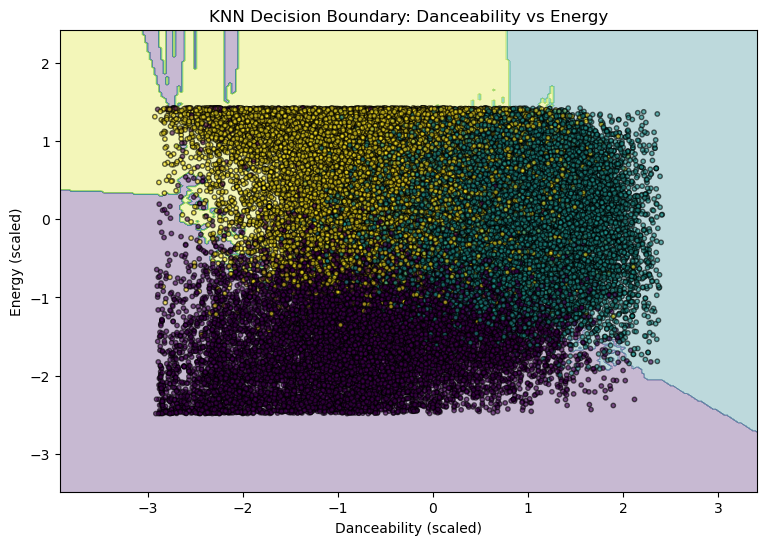

In [ ]:
import numpy as np

X_2d = df_model[["danceability", "energy"]]
y_2d = df_model["cluster"]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_train_2d_scaled, y_train_2d)

x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    s=10,
    edgecolor="k",
    alpha=0.6
)
plt.title("KNN Decision Boundary: Danceability vs Energy")
plt.xlabel("Danceability (scaled)")
plt.ylabel("Energy (scaled)")
plt.show()

### Decision Boundary

This plot shows how KNN separates songs into clusters based on danceability and energy.

It gives a visual explanation of how the model makes classification decisions.

In [ ]:
import plotly.express as px
import os
import webbrowser

pca = PCA(n_components=3)
X_test_pca = pca.fit_transform(X_test_scaled)

plot_df = pd.DataFrame({
    "PCA 1": X_test_pca[:, 0],
    "PCA 2": X_test_pca[:, 1],
    "PCA 3": X_test_pca[:, 2],
    "Actual Cluster": y_test.astype(str).values,
    "Predicted Cluster": y_pred.astype(str)
})

fig = px.scatter_3d(
    plot_df,
    x="PCA 1",
    y="PCA 2",
    z="PCA 3",
    color="Predicted Cluster",
    symbol="Actual Cluster",
    title="3D PCA Visualization of KNN Predictions"
)

fig.show()

file_path = "knn_predictions_3d.html"
fig.write_html(file_path)

full_path = os.path.abspath(file_path)
webbrowser.open("file://" + full_path)

True

## Final Conclusion

In this supervised learning bonus, I connected the project to concepts from the lecture.

I used KMeans clusters as labels and trained a KNN classifier to predict these clusters.

I practiced:

- Train/test split
- Scaling without data leakage
- KNN classification
- Confusion matrix
- Classification report
- Testing different k-values
- PCA explained variance
- Decision boundary visualization
- Model comparison with Decision Tree
- 3D PCA visualization

This shows how unsupervised and supervised machine learning can be combined in one workflow.

In [37]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df_model["anomaly"] = iso.fit_predict(X_scaled)

df_model["anomaly"].value_counts()

anomaly
 1    85103
-1     4480
Name: count, dtype: int64

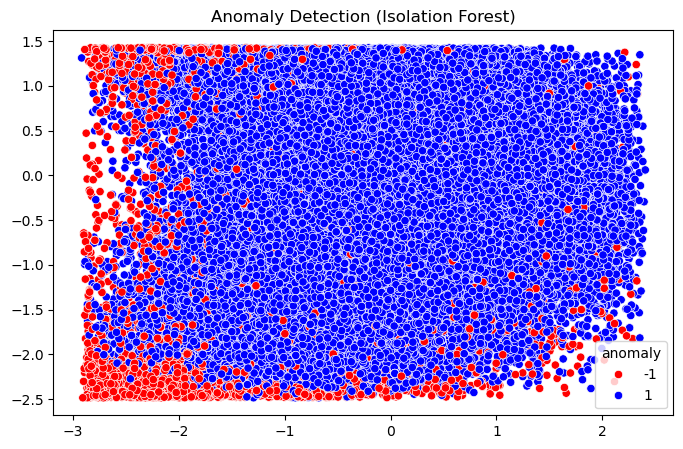

In [38]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=df_model["anomaly"],
    palette=["red", "blue"]
)

plt.title("Anomaly Detection (Isolation Forest)")
plt.show()

### Anomaly Detection

Isolation Forest was used to identify unusual songs that differ from the majority of the dataset.

The red points represent anomalies, while the blue points represent normal observations.

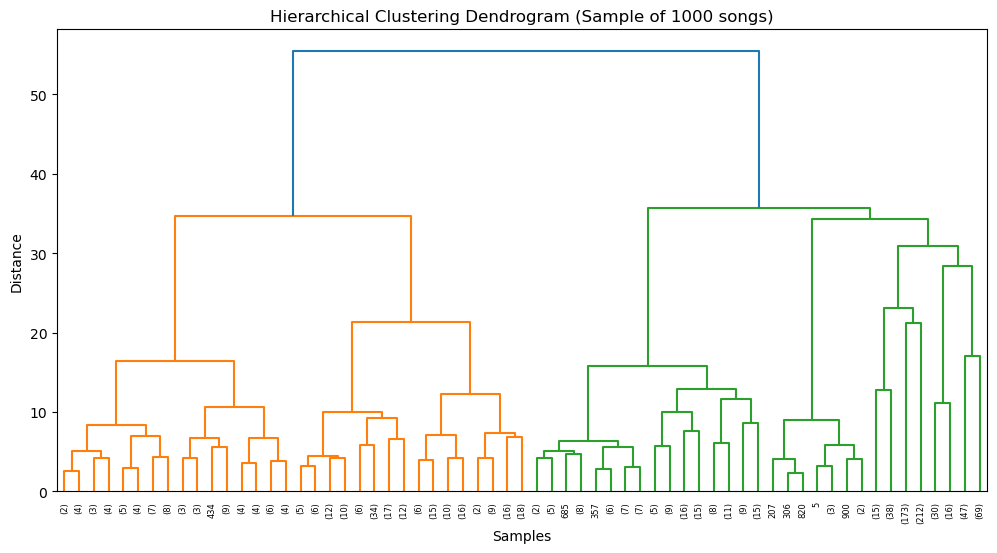

In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pandas as pd

# Ta ett mindre sample för att undvika MemoryError
sample_size = 1000

df_sample = df_model.sample(n=sample_size, random_state=42)
X_sample = df_sample[features]

scaler_sample = StandardScaler()
X_sample_scaled = scaler_sample.fit_transform(X_sample)

linked = linkage(X_sample_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram (Sample of 1000 songs)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

### Hierarchical Clustering

Hierarchical clustering was tested on a sample of the dataset because the full dataset is too large and can cause memory issues.

The dendrogram shows how songs are grouped step by step based on similarity.